In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [5]:
# Define the positive and negative classes
positive_points = np.array([(-2, 3), (0, 1), (2, -1)])
negative_points = np.array([(-2, 1), (0, -1), (2, -3)])

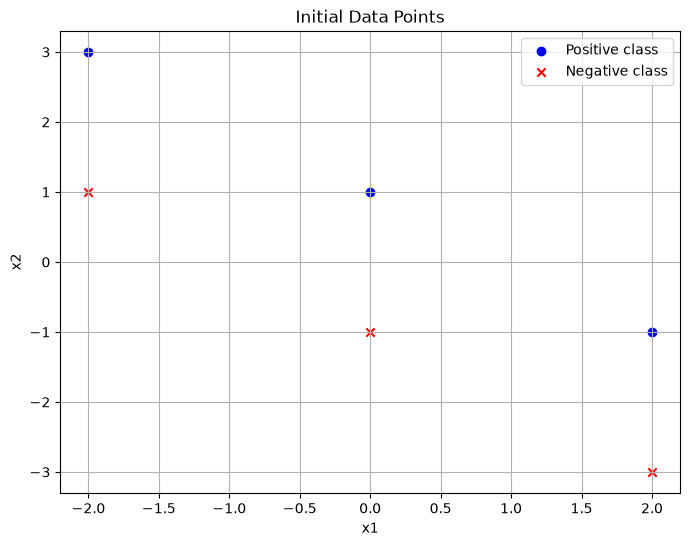

In [6]:
# Plot initial datapoints

# Plot initial data points
plt.figure(figsize=(8, 6))
plt.scatter(positive_points[:, 0], positive_points[:, 1], color='blue', marker='o', label='Positive class')
plt.scatter(negative_points[:, 0], negative_points[:, 1], color='red', marker='x', label='Negative class')
plt.legend(loc='best')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Initial Data Points')
plt.grid(True)
plt.show()

In [7]:
# Combine all points and labels
X = np.vstack((positive_points, negative_points))
y = np.array([1]*len(positive_points) + [-1]*len(negative_points))

In [8]:
X

array([[-2,  3],
       [ 0,  1],
       [ 2, -1],
       [-2,  1],
       [ 0, -1],
       [ 2, -3]])

In [9]:
y

array([ 1,  1,  1, -1, -1, -1])

**Perceptron algorithm in words:**

1. Decide the number of iterations (say 10)

2. Initialize $\theta$, $\theta_0$ to be zero

3. Start with 1st iteration

4. Go through each point in dataset and check current hypothesis prediction

5. If hypothesis makes a mistake, rotate the line so that it classifies the mistaken point correctly

6. Keep on going through all data points, and keep updating hypothesis if mistakes are made

7. After going through all data points once, start with 2<sup>nd</sup> iteration

8. Repeat 4, 5, 6, 7 till 10 iterations are done

The final hypothesis is your answer

In [10]:
def plot_decision_boundary(theta, theta0, iteration):
    plt.figure(figsize=(8, 6))
    plt.scatter(positive_points[:, 0], positive_points[:, 1], color='blue', label='Positive class')
    plt.scatter(negative_points[:, 0], negative_points[:, 1], color='red', label='Negative class')

    # Plot decision boundary
    x_values = np.linspace(-3, 3, 2)

    # Check for theta[1] to avoid division by zero in case of vertical line
    if theta[1] != 0:
        y_values = -(theta[0] * x_values + theta0) / theta[1]
        plt.plot(x_values, y_values, label=f'Iteration {iteration}')
    else:
        # Plot vertical line
        x_val = -theta0 / theta[0]
        plt.axvline(x=x_val, label=f'Iteration {iteration}')

    plt.xlim(-3, 3)
    plt.ylim(-4, 4)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Decision Boundary at Iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
# Perceptron algorithm
def perceptron(X, y, steps=10):
    theta = np.zeros(X.shape[1])
    theta0 = 0
    for t in range(steps):
        for i, xi in enumerate(X):
            if y[i] * (np.dot(xi, theta) + theta0) <= 0:
                theta += y[i] * xi
                theta0 += y[i]
                break
        # Plot after each iteration
        plot_decision_boundary(theta, theta0, t+1)
    return theta, theta0

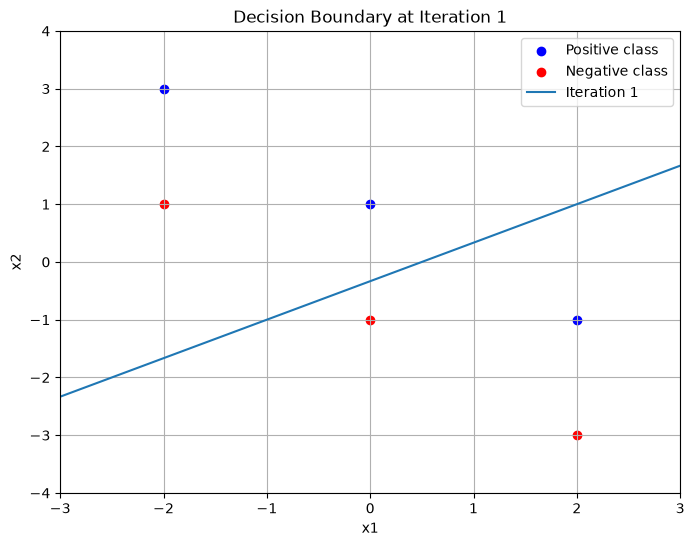

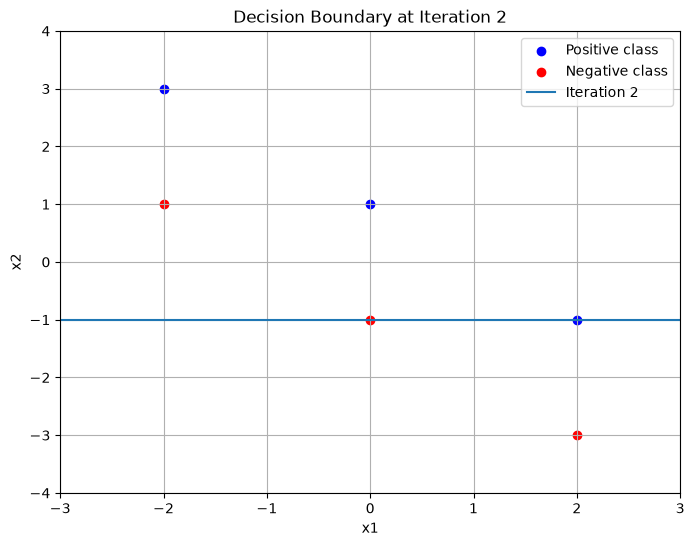

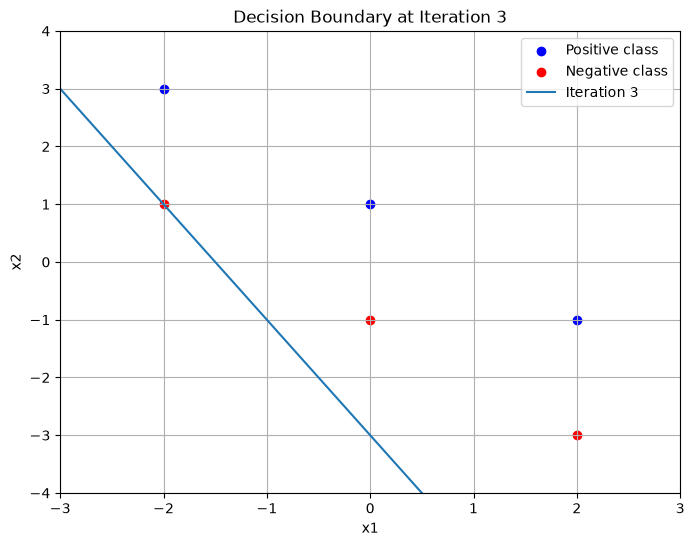

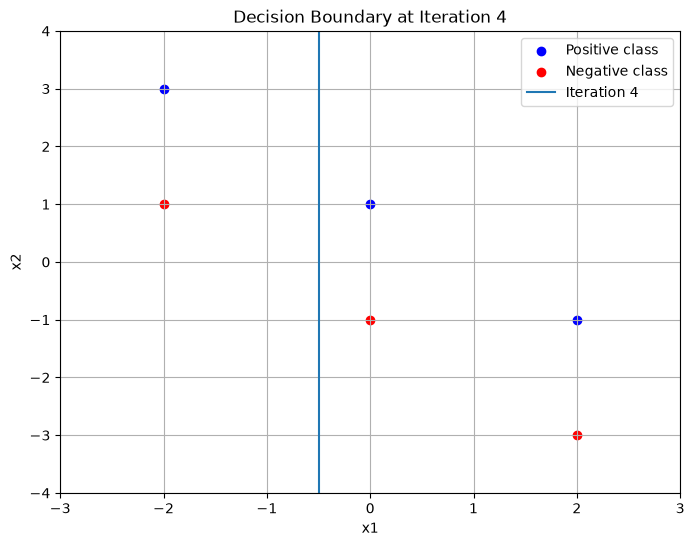

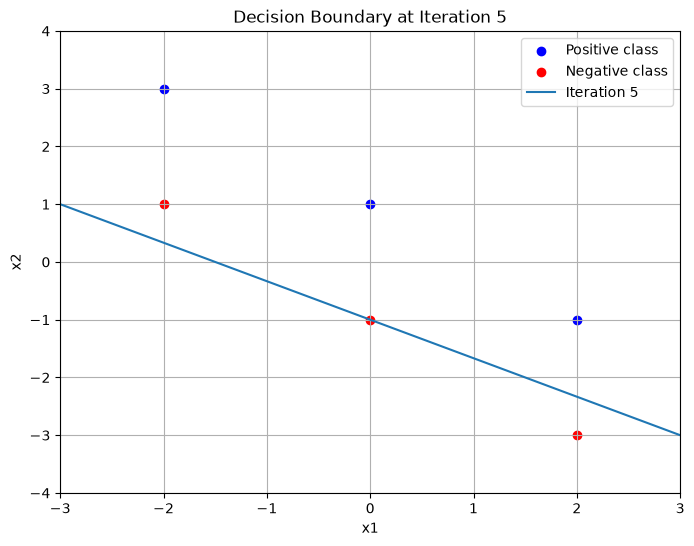

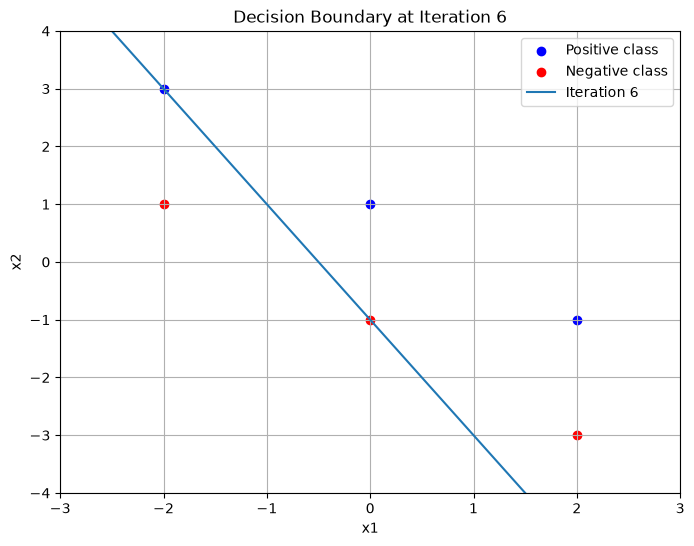

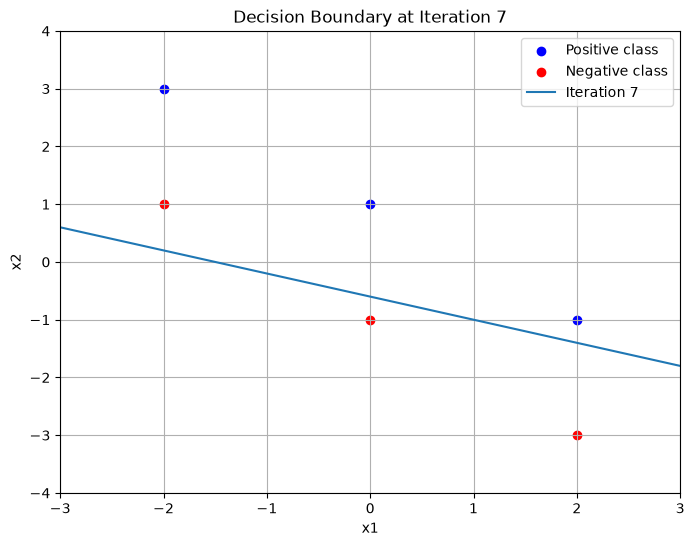

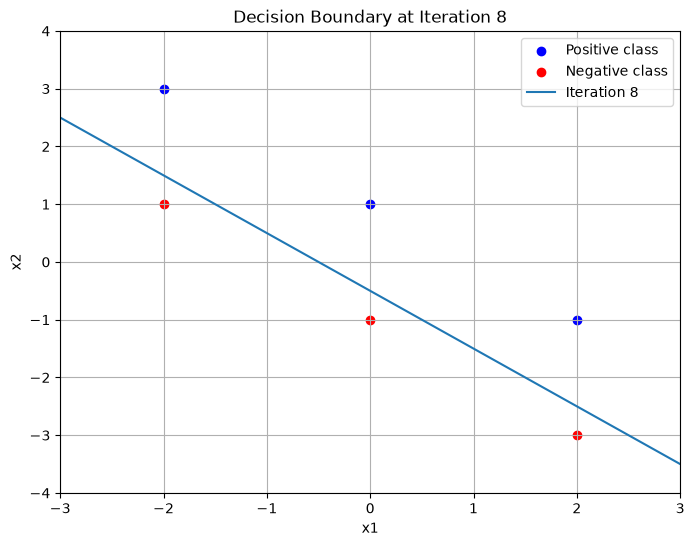

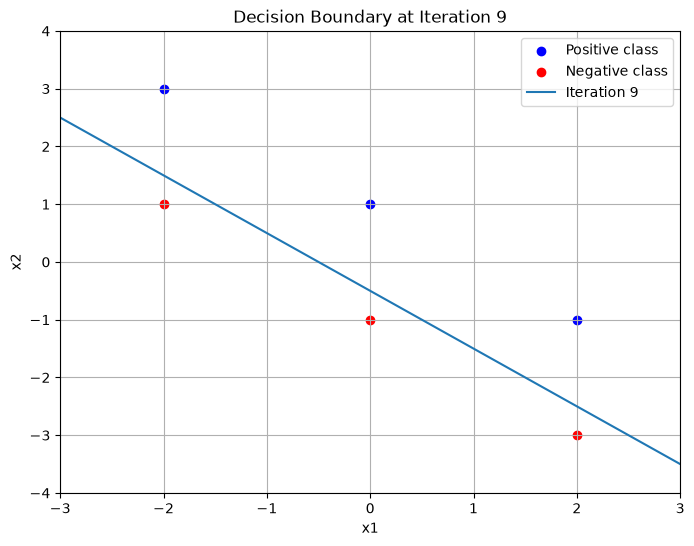

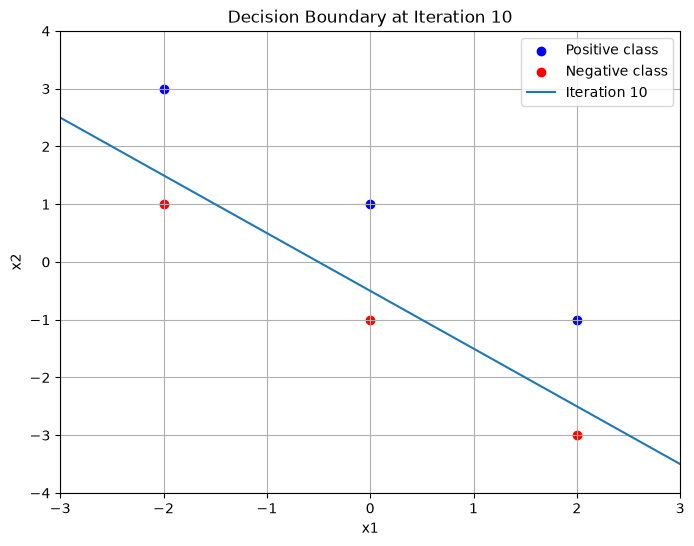

In [12]:
theta_final, theta0_final = perceptron(X, y, 10)